<a href="https://colab.research.google.com/github/EnzoGui18/Analise_Estradas/blob/main/analise_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [ ]:
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import random
import cv2

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset" / "RDD_SPLIT"

CLASSES = {0: "D00", 1: "D10", 2: "D20", 3: "D40", 4: "D43"}
CLASS_DESCRIPTIONS = {
    "D00": "Trinca Longitudinal",
    "D10": "Trinca Transversal",
    "D20": "Trinca em Jacaré",
    "D40": "Buraco",
    "D43": "Marcação Desbotada",
}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

print(f"Dataset: {DATASET_DIR}")
print(f"Classes: {list(CLASSES.values())}")

Dataset: /Users/sergiomendes/Documents/POS_IA/road-damage-yolo/dataset/RDD_SPLIT
Classes: ['D00', 'D10', 'D20', 'D40', 'D43']


# 2. Contagem por Subset

In [ ]:
def count_subset(subset_dir):
    img_dir = subset_dir / "images"
    lbl_dir = subset_dir / "labels"
    images = [f for f in img_dir.iterdir() if f.suffix.lower() in IMG_EXTS]
    labels = list(lbl_dir.glob("*.txt"))
    img_stems = {f.stem for f in images}
    lbl_stems = {f.stem for f in labels}
    return {
        "n_images": len(images),
        "n_labels": len(labels),
        "paired": len(img_stems & lbl_stems),
    }

print("📊 Contagem por subset:\n")
totals = {}
for subset in ["train", "val", "test"]:
    stats = count_subset(DATASET_DIR / subset)
    totals[subset] = stats
    print(f"  {subset}: {stats['n_images']:,} imagens, {stats['n_labels']:,} labels (pareados: {stats['paired']:,})")

total = sum(t["paired"] for t in totals.values())
print(f"\n📈 Total: {total:,} amostras pareadas")

📊 Contagem por subset:

  train: 26,869 imagens, 26,869 labels (pareados: 26,869)
  val: 5,758 imagens, 5,758 labels (pareados: 5,758)
  test: 5,758 imagens, 5,758 labels (pareados: 5,758)

📈 Total: 38,385 amostras pareadas


# 3. Distribuição de Classes

📊 Bounding boxes por classe:

subset      train   val  test  total
class_name                          
D00         18201  3890  3925  26016
D10          8386  1769  1675  11830
D20          7527  1553  1537  10617
D40          7554  1564  1587  10705
D43          4628   965   951   6544
TOTAL       46296  9741  9675  65712

📐 Proporção de cada classe:
  D00:  26,016 (39.59%)
  D10:  11,830 (18.00%)
  D20:  10,617 (16.16%)
  D40:  10,705 (16.29%)
  D43:   6,544 ( 9.96%)


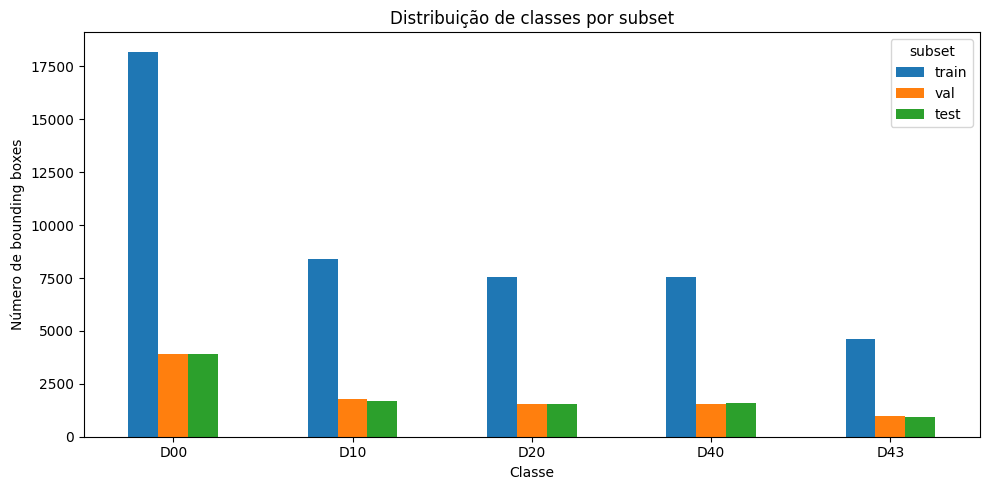

In [ ]:
def count_classes_in_subset(subset_dir):
    counts = defaultdict(int)
    for lbl_file in (subset_dir / "labels").glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                line = line.strip()
                if line:
                    counts[int(line.split()[0])] += 1
    return dict(counts)

data = []
for subset in ["train", "val", "test"]:
    counts = count_classes_in_subset(DATASET_DIR / subset)
    for cid, name in CLASSES.items():
        data.append({"subset": subset, "class_name": name, "count": counts.get(cid, 0)})

df = pd.DataFrame(data)
pivot = df.pivot(index="class_name", columns="subset", values="count")[["train", "val", "test"]]
pivot["total"] = pivot.sum(axis=1)
pivot.loc["TOTAL"] = pivot.sum(axis=0)

print("📊 Bounding boxes por classe:\n")
print(pivot.to_string())

print("\n📐 Proporção de cada classe:")
total_bb = pivot.loc["TOTAL", "total"]
for name in [CLASSES[i] for i in sorted(CLASSES.keys())]:
    c = pivot.loc[name, "total"]
    print(f"  {name}: {c:>7,} ({100*c/total_bb:5.2f}%)")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
pivot.drop("TOTAL").drop(columns="total").plot(kind="bar", ax=ax)
ax.set_title("Distribuição de classes por subset")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de bounding boxes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Distribuição do tamanho das bounding boxes


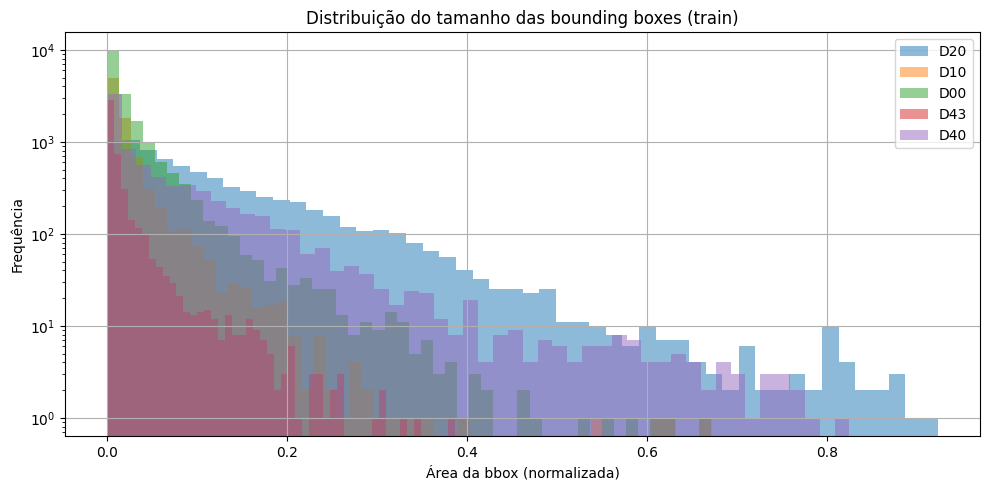


📐 Estatísticas de área (normalizada):
         count    mean     std  min     25%     50%     75%     max
class                                                              
D00    18201.0  0.0260  0.0419  0.0  0.0036  0.0115  0.0301  0.6706
D10     8386.0  0.0210  0.0332  0.0  0.0053  0.0107  0.0224  0.6725
D20     7527.0  0.1219  0.1234  0.0  0.0338  0.0818  0.1727  0.9233
D40     7554.0  0.0650  0.0964  0.0  0.0045  0.0245  0.0908  0.8246
D43     4628.0  0.0155  0.0312  0.0  0.0025  0.0053  0.0135  0.3871


In [ ]:
sizes = []
for subset in ["train"]:
    for lbl_file in (DATASET_DIR / subset / "labels").glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    w, h = float(parts[3]), float(parts[4])
                    sizes.append({"class": CLASSES[int(parts[0])], "area": w * h})

df_sizes = pd.DataFrame(sizes)

fig, ax = plt.subplots(figsize=(10, 5))
for cls in df_sizes["class"].unique():
    df_sizes[df_sizes["class"] == cls]["area"].hist(
        bins=50, alpha=0.5, label=cls, ax=ax
    )
ax.set_xlabel("Área da bbox (normalizada)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição do tamanho das bounding boxes (train)")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("\n📐 Estatísticas de área (normalizada):")
print(df_sizes.groupby("class")["area"].describe().round(4))

# 5. Exemplos visuais com bounding boxes

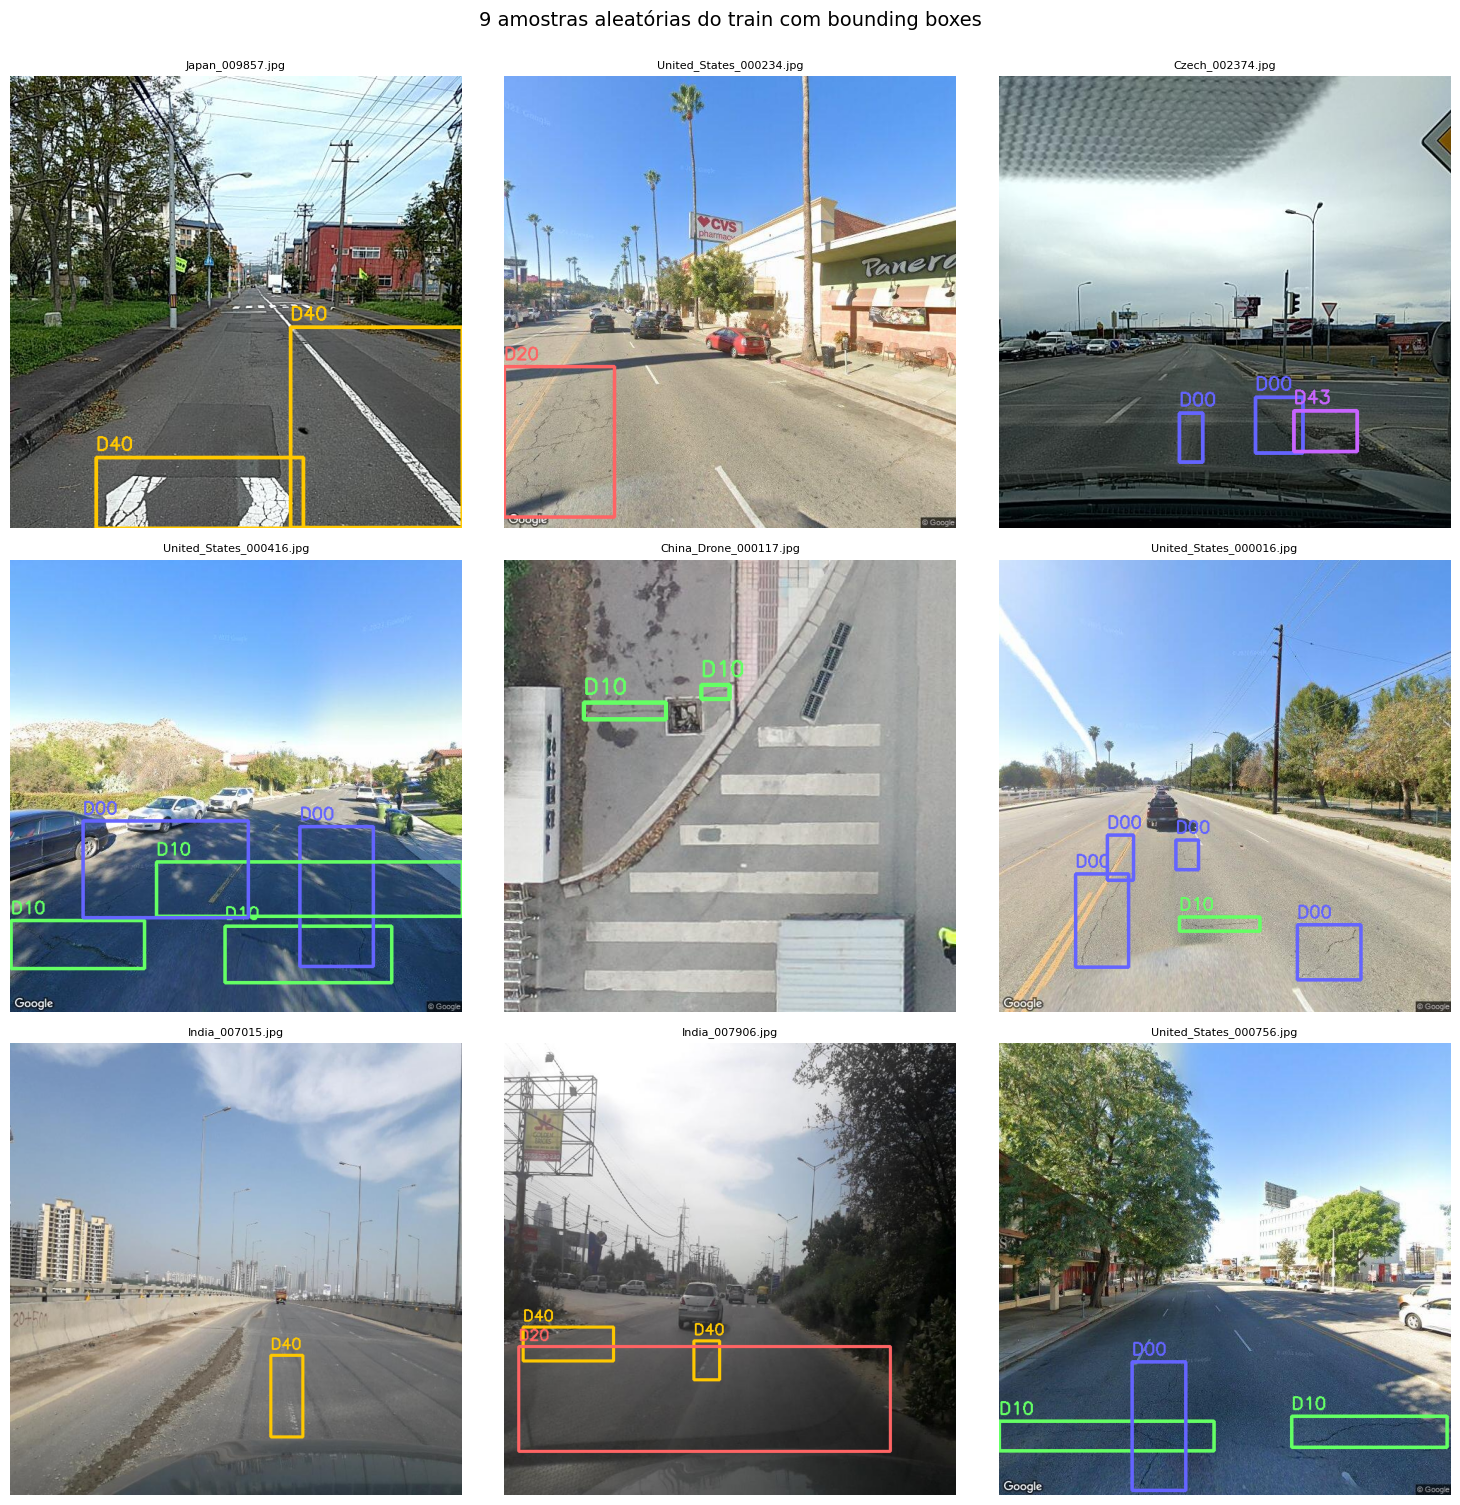

In [ ]:
random.seed(42)

CLASS_COLORS = {
    0: (100, 100, 255),
    1: (100, 255, 100),
    2: (255, 100, 100),
    3: (255, 200, 0),
    4: (200, 100, 255),
}

def draw_boxes(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if not lbl_path.exists():
        return img
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cid = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            color = CLASS_COLORS.get(cid, (255, 255, 255))
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
            cv2.putText(img, CLASSES.get(cid, "?"), (x1, max(y1-10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    return img

train_imgs = [f for f in (DATASET_DIR / "train" / "images").iterdir()
              if f.suffix.lower() in IMG_EXTS]

samples = []
random.shuffle(train_imgs)
for img_path in train_imgs:
    lbl = DATASET_DIR / "train" / "labels" / f"{img_path.stem}.txt"
    if lbl.exists() and lbl.stat().st_size > 0:
        samples.append((img_path, lbl))
    if len(samples) >= 9:
        break

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, (img_path, lbl_path) in zip(axes.flat, samples):
    ax.imshow(draw_boxes(img_path, lbl_path))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
plt.suptitle("9 amostras aleatórias do train com bounding boxes", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# 6. Análise por Origem

🌍 Imagens por origem (país):

subset         test  train   val  total
country                                
Japan          1524   7432  1550  10506
Norway         1197   5708  1256   8161
India          1166   5368  1172   7706
United_States   753   3348   704   4805
Czech           436   1962   431   2829
China_Drone     377   1675   349   2401
Outro           305   1376   296   1977


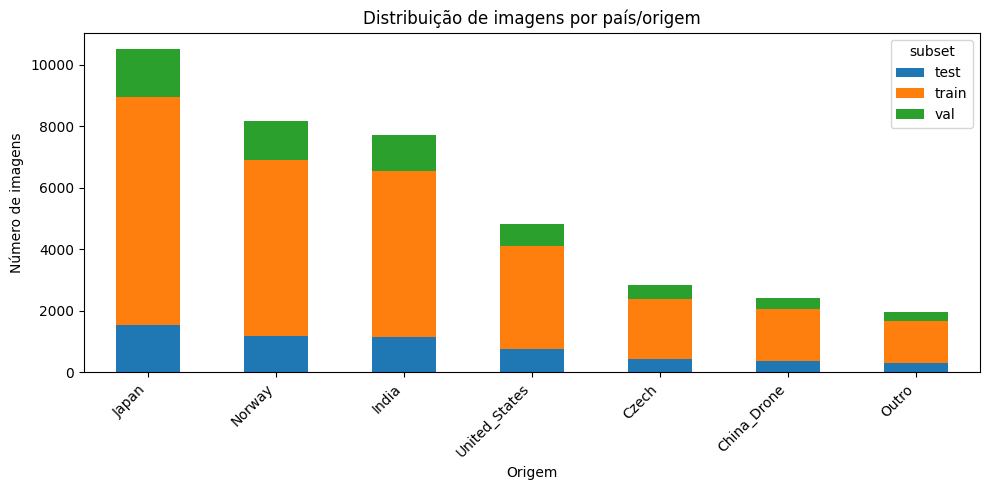

In [ ]:
# Extrai país do nome do arquivo (RDD2022 usa prefixos como "Japan_", "India_", etc.)
def extract_country(filename):
    for country in ["Japan", "India", "United_States", "China_Drone", "Czech", "Norway"]:
        if country in filename:
            return country
    return "Outro"

countries = []
for subset in ["train", "val", "test"]:
    for img in (DATASET_DIR / subset / "images").iterdir():
        if img.suffix.lower() in IMG_EXTS:
            countries.append({"subset": subset, "country": extract_country(img.name)})

df_countries = pd.DataFrame(countries)
country_pivot = df_countries.pivot_table(
    index="country", columns="subset", values="subset", aggfunc="count", fill_value=0
)
country_pivot["total"] = country_pivot.sum(axis=1)
country_pivot = country_pivot.sort_values("total", ascending=False)

print("🌍 Imagens por origem (país):\n")
print(country_pivot.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
country_pivot.drop(columns="total").plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Distribuição de imagens por país/origem")
ax.set_xlabel("Origem")
ax.set_ylabel("Número de imagens")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7. Resumo Final

In [ ]:
print("="*60)
print("📊 RESUMO DO DATASET")
print("="*60)
print(f"\nTotal de imagens: {total:,}")
print(f"Total de bounding boxes: {int(pivot.loc['TOTAL', 'total']):,}")
print(f"Média de bboxes por imagem: {pivot.loc['TOTAL', 'total'] / total:.2f}")

print(f"\n📁 Splits:")
for subset, stats in totals.items():
    pct = 100 * stats["n_images"] / total
    print(f"   {subset:5s}: {stats['n_images']:>6,} ({pct:.1f}%)")

print(f"\n🏷️ Classes (ordenadas por frequência):")
class_totals = pivot.drop("TOTAL")["total"].sort_values(ascending=False)
for name in class_totals.index:
    c = int(class_totals[name])
    pct = 100 * c / pivot.loc["TOTAL", "total"]
    desc = CLASS_DESCRIPTIONS[name]
    print(f"   {name} ({desc}): {c:>7,} ({pct:5.2f}%)")

📊 RESUMO DO DATASET

Total de imagens: 38,385
Total de bounding boxes: 65,712
Média de bboxes por imagem: 1.71

📁 Splits:
   train: 26,869 (70.0%)
   val  :  5,758 (15.0%)
   test :  5,758 (15.0%)

🏷️ Classes (ordenadas por frequência):
   D00 (Trinca Longitudinal):  26,016 (39.59%)
   D10 (Trinca Transversal):  11,830 (18.00%)
   D40 (Buraco):  10,705 (16.29%)
   D20 (Trinca em Jacaré):  10,617 (16.16%)
   D43 (Marcação Desbotada):   6,544 ( 9.96%)
